TODO: 结合stavia结果

In [1]:
import scanpy as sc

import cafe

cafe.logger.setLevel("DEBUG")

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

data: gastrulation
1. 原文: 
2. stavia: https://pyvia.readthedocs.io/en/latest/Atlas%20view%20examples.html
3. 可能参考：https://www.nature.com/articles/s41586-024-07069-w

In [2]:
fadata = cafe.data.read_erythroid_lineage()
# adata = sc.read("/root/PyCode/scRNA/data/Gastrulation/gastrulation.h5ad") # 原肠胚发育的图谱数据集
# sc.pp.subsample(adata, n_obs=20000)
# fadata = cafe.data.FateAnnData.from_anndata(adata)
fadata 

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Gastrulation/erythroid_lineage.h5ad'...                                                                                                          
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'celltype' in '.obs' columns as 'cluster' key                                                                                                                               

AnnData object with n_obs × n_vars = 9815 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'raw_index'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'

visualization

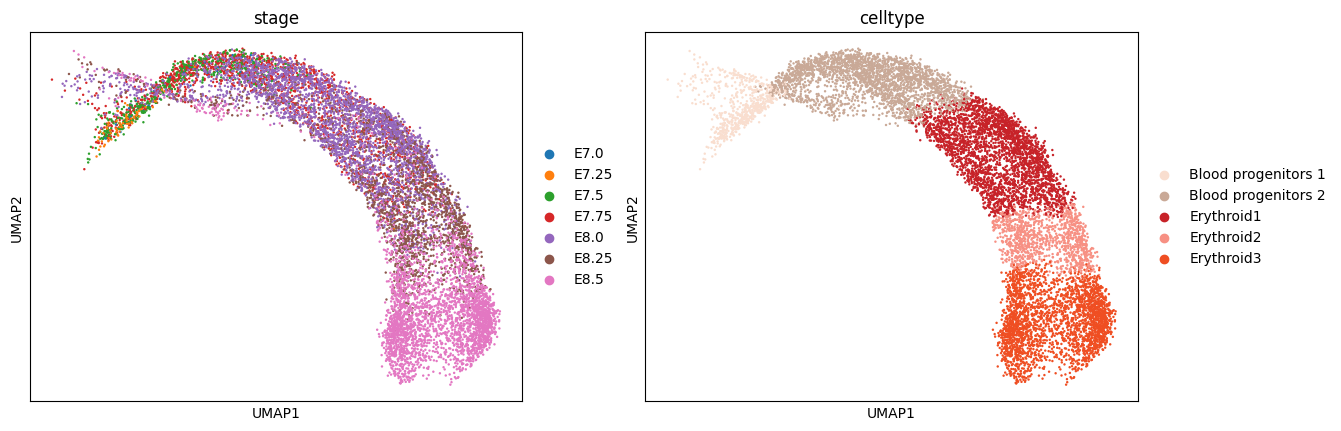

In [3]:
time_key = "stage"
cluster_key = "celltype"
sc.pl.umap(fadata, color=[time_key, cluster_key])

根据样本时间手动设置线性的里程碑网络, 后续需要准确的细胞类型注释的里程碑网络

DEBUG    |- Generating stack plot for clusters in 'fadata.obs[celltype]'...                                                                                                                             


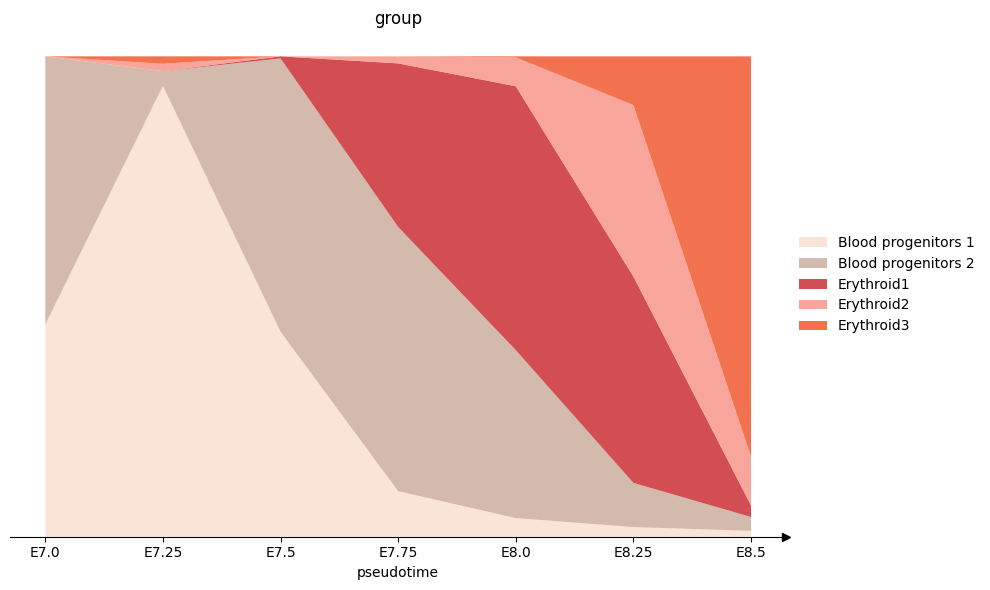

In [4]:
cafe.plot.plot_stack(fadata, pseudotime_key=time_key, cluster=cluster_key)

DEBUG    |- FateAnnData add_trajectory                                                                                                                                                                  
DEBUG    |- generate milestone color from palette.                                                                                                                                                      
INFO     |- Preparing FateAnnData for stream plotting (model: ref)                                                                                                                                      
DEBUG    |- Stream tree built with 7 nodes, 6 edges                                                                                                                                                     
INFO     |- FateAnnData prepared successfully for stream plotting                                                                                                                                   

[<Figure size 1000x600 with 1 Axes>]

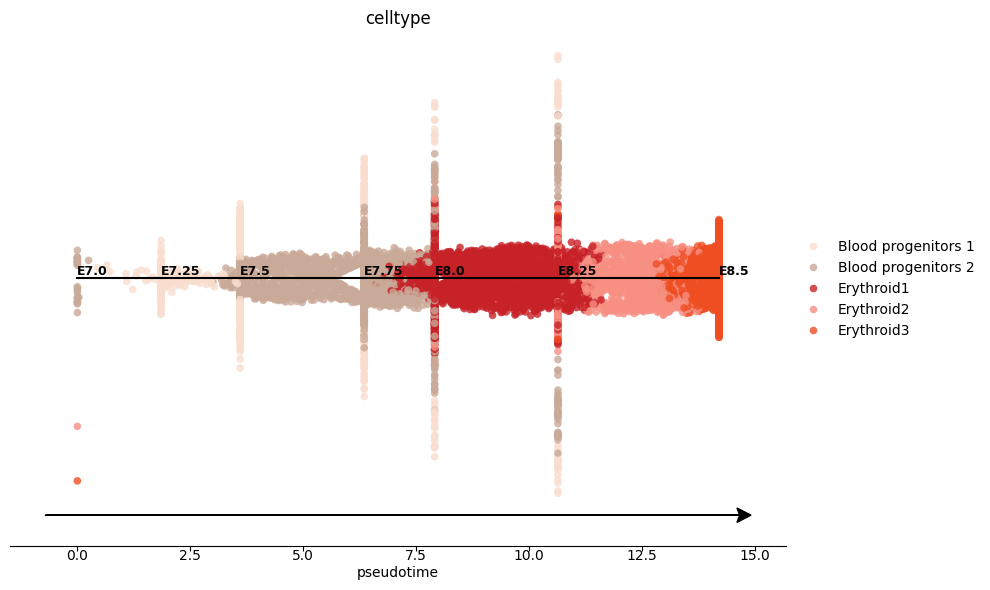

In [8]:
import pandas as pd

cluster_list = fadata.obs[time_key].cat.categories.tolist()
milestone_network = pd.DataFrame(
    data = list(zip(cluster_list[:-1], cluster_list[1:])),
    columns=["from", "to"],
)
fadata.add_trajectory_mannually(
    milestone_network=milestone_network,
    cluster_key=time_key,
)

fadata.add_prior_information(start_milestone="E6.5")
cafe.plot.plot_stream(fadata, color=cluster_key)